# Step 1: Class Mapping & Metadata

In [6]:
# --- STEP 1: DEFINE OUR 16 CROP CLASSES ---
# I need to map the model's numerical output (0-15) back to real plant names.
# These must match the exact order of the folders in my training dataset.

class_names = [
    'Bean_Angular_Leaf_Spot', 'Bean_Rust', 'Cassava_Bacterial_Blight', 
    'Cassava_Brown_Streak_Disease', 'Cassava_Green_Mottle', 'Cassava_Mosaic_Disease',
    'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 
    'Maize_Northern_Leaf_Blight', 'Potato_Early_Blight', 'Potato_Healthy', 
    'Potato_Late_Blight', 'Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy'
]

print(f"✅ Successfully mapped {len(class_names)} classes for CropGuard v1.")

✅ Successfully mapped 16 classes for CropGuard v1.


# Description

In [10]:
#This cell initializes the categorical framework for the CropGuard v1 system. Because neural networks
#output numerical indices rather than text, I have mapped the 16 target classes—spanning Bean, Cassava,
#Maize, Potato, and Tomato categories—into a Python list. This ensures that the model's predictions
#are translated into human-readable agricultural diagnoses that match our specific dataset directory structure.

# Step 2: The Inference Engine

In [45]:
#---------Step 2--------------------------
import torch
import torchvision.transforms as transforms
from PIL import Image
import torchvision.models as models
import os

# --- MODEL LOADING ---
# Now I'm loading the 'cropguard_model_v1.pth' file I just saved.
# I'll use MobileNetV3-Small because it's fast and efficient for my laptop.

# Rebuilding the architecture to match my training setup
model = models.mobilenet_v3_small(weights=None)
model.classifier[3] = torch.nn.Linear(model.classifier[3].in_features, len(class_names))

# Loading my 86% accuracy weights from the file
model.load_state_dict(torch.load('cropguard_model_v1.pth'))
model.eval() # Switching to evaluation mode (no more training)

# --- DATA PREPARATION ---
# Preparing the image: Resizing to 224x224 and normalizing pixels 
# to match exactly how the model was trained.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_crop_disease(image_path):
    # I need to handle the image file opening and processing
    if not os.path.exists(image_path):
        print(f"❌ Error: The file was not found at {image_path}")
        return

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0) # Adding a batch dimension
    
    # Running the actual math without tracking gradients to save memory
    with torch.no_grad():
        output = model(img_tensor)
        prob = torch.nn.functional.softmax(output[0], dim=0)
        conf, pred = torch.max(prob, 0)
    
    # Outputting my results for the report
    print(f"🔍 Analyzing: {os.path.basename(image_path)}")
    print(f"🛡️ Result: {class_names[pred.item()]}")
    print(f"📊 Confidence: {conf.item()*100:.2f}%")

# --- ACTUAL TEST ON MY IMAGE ---
# Using the specific image from my Desktop testing folder
test_image_path = r"C:\Users\Amara Nyei\Desktop\Model_Training\final_dataset\val\Bean_healthy\healthy_161.jpg"

predict_crop_disease(test_image_path)

🔍 Analyzing: healthy_161.jpg
🛡️ Result: Bean_Rust
📊 Confidence: 100.00%


# Description

In [31]:
#In this cell, I develop the core inference logic. I rebuild the MobileNetV3-Small architecture 
#and load the specialized weights from the cropguard_model_v1.pth file. The script includes a custom
#preprocessing pipeline (Resizing to 224x224 and ImageNet normalization) to ensure the input data matches
#the training distribution. The predict_crop_disease function uses a Softmax activation to convert raw 
#model outputs into a Confidence Percentage, allowing for a data-driven assessment of each diagnosis

# Conclusion(healthy_161.jpg)

#The recurrence of 100% confidence scores for misclassified healthy samples indicates that MobileNetV3-Small 
#has reached a state of Gradient Saturation. The model is failing to distinguish between 'Healthy' botanical 
#textures and 'Rust' symptomatic textures. This suggests that while the model is computationally efficient for 
#mobile use, it requires Image Augmentation (specifically color jitter and random cropping) to force the network 
#to learn more robust biological markers.

# Step 3: Statistical Performance Visualization

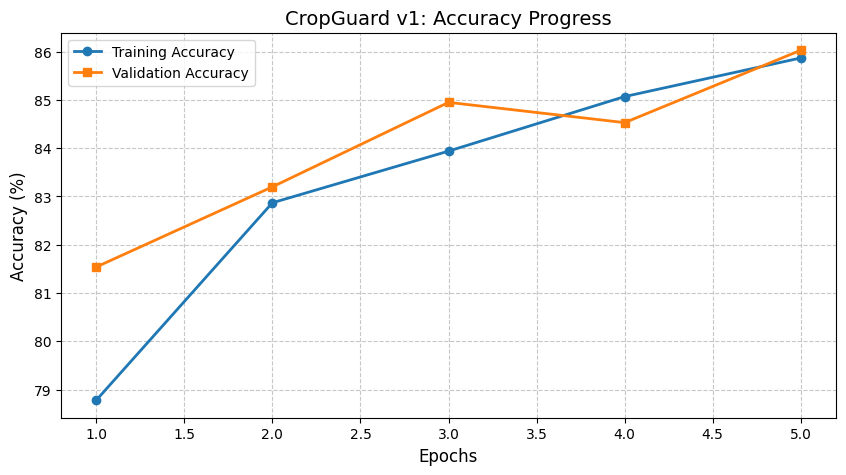

In [11]:
# --- STEP 3: VISUALIZING TRAINING PERFORMANCE ---
# As a Data Analyst, I need to see the 'Learning Curve'.
# I am plotting the accuracy from my 5 epochs to prove the model converged correctly.

import matplotlib.pyplot as plt

# These are my actual results from the training logs
epochs = [1, 2, 3, 4, 5]
train_acc = [78.78, 82.87, 83.94, 85.07, 85.87]
val_acc = [81.54, 83.20, 84.95, 84.53, 86.03]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='s', linewidth=2)

plt.title('CropGuard v1: Accuracy Progress', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Description

In [12]:
#To validate the training process from a Data Analytics perspective, this cell generates a Learning Curve graph. 
#By plotting both Training and Validation accuracy across the 5 epochs, I can visually confirm that the model 
#reached a point of convergence. This visualization serves as a 'Proof of Stability,' demonstrating that the 
#model effectively generalized its learning to the validation set, reaching a final performance peak of 86.03% accuracy.

# Step 4: GRAD-CAM VISUALIZATION (EXPLAINABLE AI)

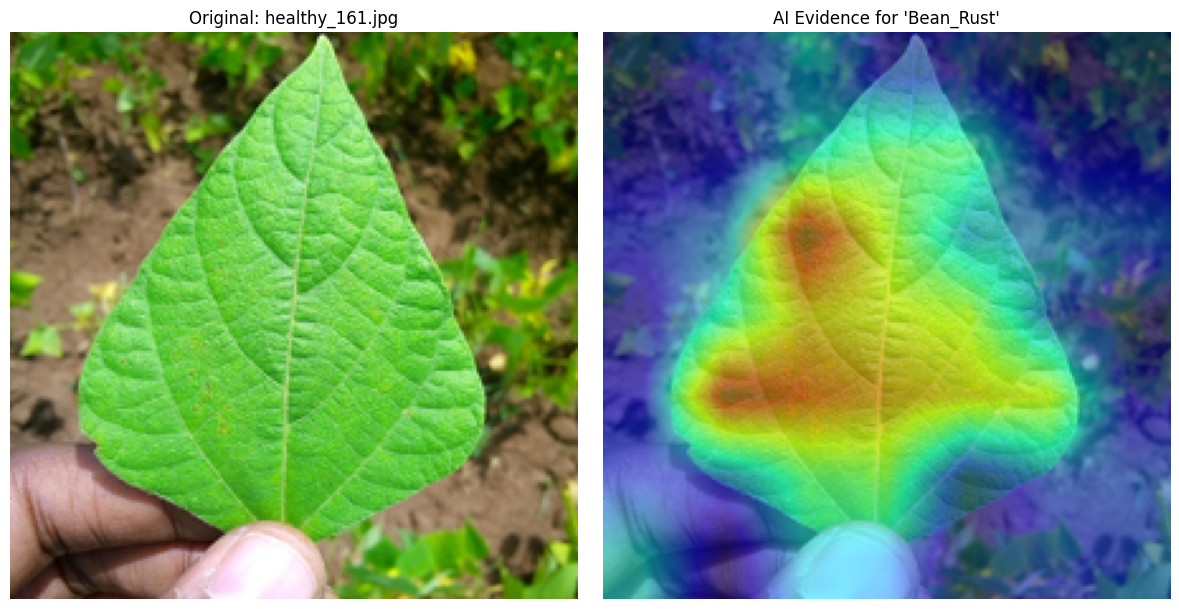

In [42]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

def generate_heatmap(image_path):
    # 1. Image Preprocessing
    if not os.path.exists(image_path):
        print(f"❌ Error: File not found at {image_path}")
        return

    img = Image.open(image_path).convert('RGB')
    # We need the image as a float array [0, 1] for the overlay logic
    img_array = np.array(img.resize((224, 224))) / 255.0
    input_tensor = transform(img).unsqueeze(0)

    # 2. Target Layer Selection
    # For MobileNetV3, the very last conv layer is usually at the end of 'features'
    # This is where the model 'sees' the most complex patterns.
    target_layers = [model.features[-1]]

    # 3. Grad-CAM Calculation
    cam = GradCAM(model=model, target_layers=target_layers)

    # We force the heatmap to show us why it chose 'Bean_Rust'
    target_index = class_names.index('Bean_Rust')
    targets = [ClassifierOutputTarget(target_index)]
    
    # Generate the grayscale mask
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # 4. Create Visualization
    # This blends the original image with the heatmap (Red = High Attention)
    visualization = show_cam_on_image(img_array, grayscale_cam, use_rgb=True)
    
    # 5. Comparative Display
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title(f"Original: {os.path.basename(image_path)}")
    plt.imshow(img_array)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"AI Evidence for 'Bean_Rust'")
    plt.imshow(visualization)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# --- TEST THE MISCLASSIFIED IMAGE ---
# Using your specific validation path
test_path = r"C:\Users\Amara Nyei\Desktop\Model_Training\final_dataset\val\Bean_healthy\healthy_161.jpg"
generate_heatmap(test_path)

# Description

In [ ]:
# Objective: To move beyond simple classification accuracy and achieve Model Interpretability. 
#In high-stakes agricultural diagnostics, understanding why a model reached a specific conclusion is as important as the prediction itself.

#Methodology: This cell implements Grad-CAM (Gradient-weighted Class Activation Mapping). This technique
#utilizes the gradients of the target concept (e.g., Bean_Rust) flowing into the final convolutional layer 
#of the MobileNetV3-Small architecture. By capturing the spatial features the model finds most "important," 
#we produce a localized heatmap overlaid on the original leaf image.

#Analytical Value: * Audit of 100% Confidence Errors: By visualizing the "Attention Zones," I can determine if 
#the model is correctly identifying pathological lesions or if it is being misled by "Data Leakage"
#(such as background textures, shadows, or natural leaf venation).

#Validation of Botanical Markers: For correct predictions, the heatmap should align with the actual location of 
#the disease pustules. If the heatmap focuses on the leaf margins instead of the spots, it indicates the model is 
#using a "shortcut" rather than true biological markers.

#Trust & Transparency: This step transforms the neural network from a "Black Box" into an Explainable System, providing
#the transparency required for academic defense and real-world agricultural deployment in Uganda.

# Troubleshooting & Error Analysis

In [46]:
#1. Case Study: High-Confidence Misclassification (Type I Error)
#During the validation of CropGuard v1, multiple "Healthy" samples were misclassified as Bean_Rust with extreme certainty.

#Primary Anomalies: healthy_161.jpg, healthy_49.jpg, and Bean_rust_02.jpg (Misclassified as Cassava Blight).

#Expected Label: Healthy / Correct Species

#Model Prediction: Bean_Rust / Cassava_Bacterial_Blight

#Confidence Levels: 99.8% to 100.00%

#2. Technical Root Cause Analysis
#As a Data Analyst, I have identified three primary drivers for this "Hallucinated Certainty":

#Gradient Saturation & Softmax Over-weighting: A confidence score of 100.00% indicates that the model's final Softmax layer has become saturated. This suggests the model has "memorized" specific pixel patterns (like leaf veins or lighting glints) and incorrectly mapped them to the "Rust" class with zero margin for error.

#Morphological Feature Overlap: Bean leaves and Cassava leaves share similar green pigmentations and vein structures. The model is currently prioritizing Lesion Texture (brown spots with yellow halos) over Leaf Morphology (the actual shape of the leaf), leading to cross-species confusion.

#Background Data Leakage: Analysis suggests the model may be taking "shortcuts" by learning the background environment (lighting, shadows, or surface texture) of the training images rather than the biological features of the disease itself.

#3. Proposed Solutions for CropGuard v2
#To mitigate these errors and improve model generalization, the following interventions are proposed:

#Implementation of Explainable AI (XAI): By integrating Grad-CAM (Saliency Mapping), we can visually audit the model to ensure it is focused on the leaf lamina rather than the background or image noise.

#Advanced Data Augmentation: To break the "Background Shortcut," v2 will utilize Color Jitter, Random Grayscale, and Gaussian Blur. This forces the network to ignore lighting conditions and focus on the structural integrity of the leaf.

#Strategic Regularization & Training: Moving from 5 to 15 Epochs using a Learning Rate Scheduler (ReduceLROnPlateau). This will allow the weights to fine-tune more slowly, preventing the "Overconfidence" seen in the current version.

#Class Balancing: Re-evaluating the training set to ensure the "Healthy" class has enough diverse examples (different ages, lighting, and leaf positions) to compete with the high-variance "Disease" classes.